# DBSCAN Density-based Clustering

In [ ]:
# Remember: library imports are ALWAYS at the top of the script, no exceptions!
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from math import ceil

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans

## New imports
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, estimate_bandwidth

sns.set()

In [ ]:
## Un-comment these if you want to use ydata_profiling

# !pip install -U ydata-profiling
# from ydata_profiling import ProfileReport


## Context
The data we will be using through the pratical classes comes from a small relational database whose schema can be seen below:
![Schema](https://raw.githubusercontent.com/fpontejos/DMDM_2223/main/figures/schema.png "Relation database schema")

## Reading the Data

In [ ]:
## Allow Colab to see Google Drive files

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## Load csv file into a dataframe
## Paste the path here
data_path = "/content/drive/MyDrive/Colab Data/datamining.csv"

df = pd.read_csv(data_path)

In [ ]:
## Load csv file into a dataframe
## Alternative location of the csv file

## data_path = "https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/datamining.csv"

## df = pd.read_csv(data_path)

### Make a copy of your original dataset

why?

In [ ]:
df_original = df.copy()

### Metadata
- *id* - The unique identifier of the customer
- *age* - The year of birht of the customer
- *income* - The income of the customer
- *frq* - Frequency: number of purchases made by the customer
- *rcn* - Recency: number of days since last customer purchase
- *mnt* - Monetary: amount of € spent by the customer in purchases
- *clothes* - Number of clothes items purchased by the customer
- *kitchen* - Number of kitchen items purchased by the customer
- *small_appliances* - Number of small_appliances items purchased by the customer
- *toys* - Number of toys items purchased by the customer
- *house_keeping* - Number of house_keeping items purchased by the customer
- *dependents* - Binary. Whether or not the customer has dependents
- *per_net_purchase* - Percentage of purchases made online
- *education* - Education level of the customer
- *status* - Marital status of the customer
- *gender* - Gender of the customer
- *description* - Last customer's recommendation description

## Preprocess the Data

Remember what we did in the previous session

In [ ]:
# Sometimes it is not obvious that a value is missing
# For example if the value is an empty string

# replace "" by nans
df.replace("", np.nan, inplace=True)

In [ ]:
# Define metric and non-metric features. Why?
non_metric_features = ["education", "status", "gender", "dependents", "description"]

## This is saying that the metric features are all the other features that are not non-metric
## Need to be careful in case not all columns are to be used as features

# metric_features = df.columns.drop(non_metric_features).to_list()

## Or you can also specify manually
metric_features = ['age',
 'income',
 'frq',
 'rcn',
 'mnt',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase']

### Fill missing values (Data imputation)

How can we fill missing values?


#### Using measures of central tendency

In [ ]:
# Creating a copy to apply central tendency measures imputation
df_central = df.copy()

In [ ]:
# count of missing values
df_central.isna().sum()

Unnamed: 0            0
age                   0
income               46
frq                   0
rcn                   0
mnt                   0
clothes               0
kitchen               0
small_appliances      0
toys                  0
house_keeping         0
dependents          282
per_net_purchase      0
gender                0
education            47
status              177
description           0
dtype: int64

In [ ]:
medians = df_central[metric_features].median()
medians

age                  1966.0
income              70030.5
frq                    17.0
rcn                    53.0
mnt                   383.0
clothes                51.0
kitchen                 4.0
small_appliances       28.0
toys                    4.0
house_keeping           4.0
per_net_purchase       45.0
dtype: float64

In [ ]:
modes = df_central[non_metric_features].mode().loc[0]
modes

education      Graduation
status            Married
gender                  M
dependents            1.0
description      OK nice!
Name: 0, dtype: object

In [ ]:
## Fill NaNs using medians and modes

df_central.fillna(medians, inplace=True)
df_central.fillna(modes, inplace=True)

In [ ]:
df_central.isna().sum()  # checking how many NaNs we still have

Unnamed: 0          0
age                 0
income              0
frq                 0
rcn                 0
mnt                 0
clothes             0
kitchen             0
small_appliances    0
toys                0
house_keeping       0
dependents          0
per_net_purchase    0
gender              0
education           0
status              0
description         0
dtype: int64

In [ ]:
df = df_central.copy()

### Outlier removal

In [ ]:
def remove_outliers(df, filters):

  df_2 = df[filters]
  print('Percentage of data kept after removing outliers:', 100*(np.round(df_2.shape[0] / df.shape[0], 4)))

  return df_2



In [ ]:
# This may vary from session to session, and is prone to varying interpretations.
# A simple example is provided below:

manual_filters = (
    (df['house_keeping']<=50)
    &
    (df['kitchen']<=40)
    &
    (df['toys']<=35)
    &
    (df['education']!='OldSchool')
)

df_1 = remove_outliers(df, manual_filters)

Percentage of data kept after removing outliers: 97.99


In [ ]:
# Get the manual filtering version
df = df_1.copy()

In [ ]:
# How can we avoid having as many extreme values in 'rcn'?
print((df['rcn']>100).value_counts())

rcn_t = df['rcn'].copy()
rcn_t.loc[rcn_t>100] = 100

df['rcn'] = rcn_t

False    8437
True      380
Name: rcn, dtype: int64


#### What about non-metric features?

In [ ]:
# Let's also remove status=Whatever
df.loc[df['status'] == 'Whatever', 'status'] = df['status'].mode()[0]


### Feature Engineering and Feature Selection

In [ ]:
df['birth_year'] = df['age']
df['age'] = datetime.now().year - df['birth_year']

df['spent_online'] = (df['per_net_purchase'] / 100) * df['mnt']

#### Redundancy


In [ ]:
# Select variables according to their correlations
df.drop(columns=['birth_year', 'age', 'mnt'], inplace=True)

In [ ]:
# Updating metric_features
metric_features.append("spent_online")
metric_features.remove("mnt")
metric_features.remove("age")

In [ ]:
metric_features

['income',
 'frq',
 'rcn',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase',
 'spent_online']

#### Relevancy
Selecting variables based on the relevancy of each one to the task. Example: remove uncorrelated variables with the target, stepwise regression, use variables for product clustering, use variables for socio-demographic clustering, ...

Variables that aren't correlated with any other variable are often also not relevant. In this case we will not focus on this a lot since we don't have a defined task yet.

### Data Normalization

#### Standard Scaling

In [ ]:
df_standard = df.copy()

In [ ]:
scaler = StandardScaler()
scaled_feat = scaler.fit_transform(df_standard[metric_features])
df_standard[metric_features] = scaled_feat


In [ ]:
df = df_standard.copy()

### One-hot encoding

In [ ]:
df_ohc = df.copy()

In [ ]:
def get_ohc_df(df, feats):
  # Use OneHotEncoder to encode the categorical features.
  # Get feature names and create a DataFrame
  # with the one-hot encoded categorical features (pass feature names)

  ohc = OneHotEncoder(sparse_output=False, drop="first")
  ohc_feat = ohc.fit_transform(df[feats])
  ohc_feat_names = ohc.get_feature_names_out()
  ohc_df = pd.DataFrame(ohc_feat, index=df.index, columns=ohc_feat_names)

  # Reassigning df to contain ohc variables
  df_ohc = pd.concat([df, ohc_df], axis=1)

  ## Return the df with the one-hot encoded features
  ## Also return the OneHotEncoder model (ohc)
  return df_ohc, ohc

df_ohc, ohc = get_ohc_df(df, non_metric_features)


In [ ]:
oh_features = ohc.get_feature_names_out().tolist()
oh_features

['education_2nd Cycle',
 'education_Graduation',
 'education_Master',
 'education_PhD',
 'status_Married',
 'status_Single',
 'status_Together',
 'status_Widow',
 'gender_M',
 'dependents_1.0',
 'description_Kind of OK',
 'description_Meh...',
 'description_OK nice!',
 'description_Take my money!!']

In [ ]:
df_ohc.columns

Index(['Unnamed: 0', 'income', 'frq', 'rcn', 'clothes', 'kitchen',
       'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description',
       'spent_online', 'education_2nd Cycle', 'education_Graduation',
       'education_Master', 'education_PhD', 'status_Married', 'status_Single',
       'status_Together', 'status_Widow', 'gender_M', 'dependents_1.0',
       'description_Kind of OK', 'description_Meh...', 'description_OK nice!',
       'description_Take my money!!'],
      dtype='object')

In [ ]:
df = df_ohc.copy()

## DBSCAN (Density-based spatial clustering of applications with noise)

What is DBSCAN clustering? How does it work?



DBSCAN animation            |  Core, border and noise
:-------------------------:|:-------------------------:
![](https://raw.githubusercontent.com/fpontejos/DM1_2324/main/figures/dbscan.gif)  |  ![](https://raw.githubusercontent.com/fpontejos/DM1_2324/main/figures/dbscan.jpg)


### Characteristics:
- No need to define number of clusters apriori
- Resistant to noise and outliers
- Can identify outliers
- Can handle clusters of different shapes and sizes
- Depends highly on the epsilon hyperparameter and it can be hard to tune
- Does not work well with clusters of varying densities

In [ ]:
# Perform DBSCAN clustering
dbscan = DBSCAN(eps=1.5, min_samples=20, n_jobs=4)
dbscan_labels = dbscan.fit_predict(df[metric_features])

dbscan_n_clusters = len(np.unique(dbscan_labels))
print("Number of estimated clusters  : %d" % dbscan_n_clusters)

## How many data points in each cluster?
print("Counter of cluster labels     :", Counter(dbscan_labels))
print("Percentage of noise rows      :", round(100*Counter(dbscan_labels)[-1]/df.shape[0],2))

Number of estimated clusters  : 2
Counter of cluster labels     : Counter({0: 8024, -1: 793})
Percentage of noise rows      : 8.99


### Defining eps and min_samples:
- **min_samples**: As a rule of thumb, **min_samples = 2 x dim** can be used, but it may be necessary to choose larger values for very large data, for noisy data or for data that contains many duplicates.

- **ε**: The value for ε can then be chosen by using a **k-distance graph**, plotting the distance to the kth (k = minPts - 1) nearest neighbor ordered from the largest to the smallest value. Good values of ε are where this plot shows an **"elbow"**: if ε is chosen much too small, a large part of the data will not be clustered; whereas for a too high value of ε, clusters will merge and the majority of objects will be in the same cluster. **The assumption is that for points in a cluster, their k nearest neighbors are at roughly the same distance**. Noise points have their k-th nearest neighbors at farther distance

In [ ]:
def plot_kdist_graph(df, feats, n_neighbors=20):
  # K-distance graph to find out the right eps value
  ## For each data point, we calculate the average distance
  ## to its n_neighbors

  neigh = NearestNeighbors(n_neighbors=n_neighbors)
  neigh.fit(df[feats])
  distances, _ = neigh.kneighbors(df[feats])

  ## We sort the average distances of the points
  ## And plot this
  distances = np.sort(distances[:, -1])
  plt.ylabel("%d-NN Distance" % n_neighbors)
  plt.xlabel("Points sorted by distance")
  plt.plot(distances)
  plt.show()



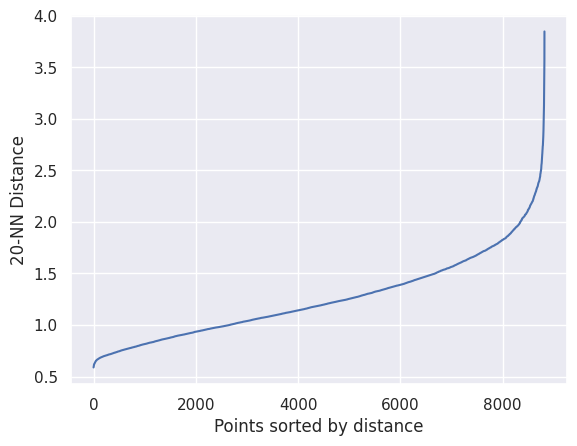

In [ ]:
plot_kdist_graph(df, metric_features)
## The "Knee" or the threshold before we get very large distances (y-axis)
## is at around 1.8 to 2.0

In [ ]:
# Based on the hyperparameters we found

dbscan = DBSCAN(eps=1.9, min_samples=20, n_jobs=4)
dbscan_labels = dbscan.fit_predict(df[metric_features])

print("Points in cluster -1 are noise rows.")
print("Counter of cluster labels     :", Counter(dbscan_labels))
print("Percentage of noise rows      :", round(100*Counter(dbscan_labels)[-1]/df.shape[0],2))

Points in cluster -1 are noise rows.
Counter of cluster labels     : Counter({0: 8715, -1: 102})
Percentage of noise rows      : 1.16


In [ ]:
def split_noise_rows(df, feats, dbs_model):
  ## Splits the dataframe into noise and non-noise
  dbscan_labels = dbs_model.fit_predict(df[feats])

  df_concat = pd.concat([df,
                         pd.Series(dbscan_labels,
                                   name='dbscan_labels',
                                   index=df.index)],
                            axis=1)

  df_noise = df_concat[df_concat['dbscan_labels']==-1].copy()
  df_nonoise = df_concat[df_concat['dbscan_labels']==0].copy()


  return df_noise, df_nonoise, df_concat

In [ ]:
## Use hyperparameters we found before

dbscan = DBSCAN(eps=1.9, min_samples=20, n_jobs=4)
df_noise, df_nonoise, df_combined_noise = split_noise_rows(df, metric_features, dbscan)

In [ ]:
print("There are %d noise rows (%f pct)" % (df_noise.shape[0], 100*df_noise.shape[0]/df_combined_noise.shape[0]))
print("There are %d non-noise rows (%f pct)" % (df_nonoise.shape[0], 100*df_nonoise.shape[0]/df_combined_noise.shape[0]))

There are 102 noise rows (1.156856 pct)
There are 8715 non-noise rows (98.843144 pct)


In [ ]:
## Rename df_nonoise dataframe to df for simplicity
## Remember the df_combined_noise dataframe has both noise and non noise rows

print(df_combined_noise.shape)
print(df_nonoise.shape)
print(df_noise.shape)

df = df_nonoise.copy()



(8817, 31)
(8715, 31)
(102, 31)


## Next: Clustering by Perspectives


## [OPTIONAL] Exercise

To practice your clustering skills, you can do the same exercises on a different dataset.


The Spaceship Titanic Dataset has been loaded for you in the cells below. You can find more information about this dataset from the Kaggle link.


Using this notebook as a guide, try to answer the questions that follow.


---

Addison Howard, Ashley Chow, Ryan Holbrook. (2022). Spaceship Titanic. Kaggle. https://kaggle.com/competitions/spaceship-titanic


In [ ]:
titanic_df = pd.read_csv("https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/spaceship_titanic_dataset.csv")


In [ ]:
## Keep only the useful features that you identified in the previous exercise

titanic_metric_features = []
titanic_non_metric_features = []


In [ ]:
titanic_metric_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
titanic_non_metric_features = ['HomePlanet', 'CryoSleep', 'Destination','VIP', 'Transported']


In [ ]:
## Don't forget to do the preprocessing steps you performed in the previous exercise


In [ ]:
titanic_df['Name'].replace(np.nan, "NO_NAME", inplace=True)
titanic_df['Cabin'].replace(np.nan, "NO_CABIN", inplace=True)

## Replace missing values using one of the methods shown previously
titanic_central = titanic_df.copy()

titanic_medians = titanic_central[titanic_metric_features].median()
titanic_modes = titanic_central[titanic_non_metric_features].mode().loc[0]

titanic_central.fillna(titanic_medians, inplace=True)
titanic_central.fillna(titanic_modes, inplace=True)

titanic_df = titanic_central.copy()


## Outlier treatment
## Use manual filters
titanic_manual_filters = (
    (titanic_df['RoomService']<=8000)
    &
    (titanic_df['FoodCourt']<=20000)
    &
    (titanic_df['ShoppingMall']<=7500)
    &
    (titanic_df['Spa']<=11000)
    &
    (titanic_df['VRDeck']<=12000)
)

titanic_df_1 = remove_outliers(titanic_df, titanic_manual_filters)
titanic_df = titanic_df_1.copy()


# Use StandardScaler to scale the data
titanic_std = titanic_df.copy()
titanic_scaler = StandardScaler()
titanic_scaled_feat = titanic_scaler.fit_transform(titanic_std[titanic_metric_features])
titanic_std[titanic_metric_features] = titanic_scaled_feat

titanic_df = titanic_std.copy()

## One-hot encode categorical features
titanic_df_ohc, titanic_ohc = get_ohc_df(titanic_df, titanic_non_metric_features)

titanic_df = titanic_df_ohc.copy()

Percentage of data kept after removing outliers: 99.41


In [ ]:
## Use DBSCAN to identify and separate noise rows
## making sure to use the appropriate hyperparameters such as eps and min_samples


In [ ]:
len(titanic_metric_features)

6

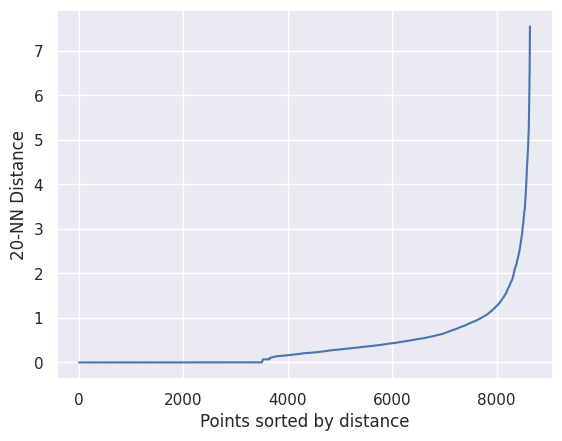

In [ ]:
## Remember rule of thumb for n_neighbors
plot_kdist_graph(titanic_df, titanic_metric_features)

In [ ]:
# Based on the hyperparameters we found

## Based on graph, "knee" / elbow point around 1.2-1.4
## min_samples = len(titanic_metric_features) * 2 = 6 * 2 = 12

dbscan_titanic = DBSCAN(eps=1.3, min_samples=12, n_jobs=4)
dbscan_titanic_labels = dbscan_titanic.fit_predict(titanic_df[titanic_metric_features])

print("Points in cluster -1 are noise rows.")
print("Counter of cluster labels     :", Counter(dbscan_titanic_labels))
print("Percentage of noise rows      :", round(100*Counter(dbscan_titanic_labels)[-1]/titanic_df.shape[0],2))

Points in cluster -1 are noise rows.
Counter of cluster labels     : Counter({0: 8327, -1: 315})
Percentage of noise rows      : 3.64


In [ ]:
dft_noise, dft_nonoise, dft_combined_noise = split_noise_rows(titanic_df, titanic_metric_features, dbscan_titanic)

In [ ]:
## Rename df_nonoise dataframe to df for simplicity
## Remember the df_combined_noise dataframe has both noise and non noise rows

print(dft_combined_noise.shape)
print(dft_nonoise.shape)
print(dft_noise.shape)

titanic_df = dft_nonoise.copy()



(8642, 22)
(8327, 22)
(315, 22)
